# Paper-Faithful CRNN-DF + Sparse-FBGAN

Complete updated notebook for the BCI Competition IV 2a replication pipeline.

### Included
- Dataset loading and validation
- Fold preprocessing
- Corrected FBCSP projection
- LASSO sparse feature selection
- CRNN-DF with warm-up and discriminative feature loss
- Differentiable sparse filter-bank path
- Class-specific FBGAN training
- Synthetic EEG generation
- Quality diagnostics
- Single-subject demo
- Full LOSO evaluation
- Paper comparison plots and confusion matrices

Run the notebook from top to bottom. Keep `eeg_bundle.pkl` in the same working directory as the notebook.

In [1]:
# ================================================================
# PAPER-FAITHFUL CRNN-DF + SPARSE-FBGAN
# COMPLETE UPDATED RUN-READY VERSION
#
# Required file beside this script:
#   eeg_bundle.pkl
#
# Expected bundle keys:
#   X_raw, y, subjects, sessions
# Optional:
#   S0, S1

In [2]:
# ================================================================

import os
import gc
import time
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt, welch
from scipy.linalg import eigh

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# ================================================================
# 1. REPRODUCIBILITY AND DEVICE

In [4]:
# ================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [5]:
# ================================================================
# 2. CONFIGURATION

In [6]:
# ================================================================

BUNDLE_PATH = "eeg_bundle.pkl"

FS = 250
N_CH = 22
N_T = 1000
N_CLASSES = 4

CLASSES = [
    "Left hand",
    "Right hand",
    "Feet",
    "Tongue",
]

BANDS = [
    (1, 4),
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32),
    (32, 35),
    (35, 38),
]

CSP_PER_CLASS = 4
LASSO_MIN = 8
LASSO_MAX = 64

CRNN_EPOCHS = 200
WARMUP = 30
CRNN_BATCH = 32
CRNN_LR = 1e-4

LAM_CENTER = 0.10
LAM_INTER = 0.01
CENTER_ALPHA = 0.5
DROPOUT = 0.5

NOISE_DIM = 256
GAN_EPOCHS = 300
GAN_BATCH = 16
GAN_LR_G = 2e-4
GAN_LR_D = 2e-4

N_FAKE_PER_CLASS = 750

# First validate A1.
RUN_DEMO = True
DEMO_SUBJECT = "1"

# Change to True only after demo succeeds.
RUN_FULL_LOSO = False

PAPER_CRNN = {
    "1": 65.51,
    "2": 45.18,
    "3": 78.62,
    "4": 53.58,
    "5": 55.64,
    "6": 56.03,
    "7": 71.28,
    "8": 75.02,
    "9": 70.78,
}

PAPER_GAN = {
    "1": 79.60,
    "2": 54.25,
    "3": 83.84,
    "4": 60.93,
    "5": 70.54,
    "6": 62.18,
    "7": 79.94,
    "8": 82.01,
    "9": 81.36,
}

In [7]:
# ================================================================
# 3. LOAD DATA

In [8]:
# ================================================================

assert os.path.exists(BUNDLE_PATH), (
    f"{BUNDLE_PATH} not found. Put it beside this script."
)

with open(BUNDLE_PATH, "rb") as f:
    bundle = pickle.load(f)

X_raw = np.asarray(bundle["X_raw"], dtype=np.float32)
y = np.asarray(bundle["y"], dtype=np.int64)
subjects = np.asarray(bundle["subjects"]).astype(str)
sessions = np.asarray(bundle["sessions"]).astype(str)

unique_sessions = sorted(np.unique(sessions))

S0 = str(bundle.get("S0", unique_sessions[0]))
S1 = str(bundle.get("S1", unique_sessions[1]))

print("Data shape:", X_raw.shape)
print("Class counts:", np.bincount(y, minlength=N_CLASSES))
print("Subjects:", sorted(np.unique(subjects), key=lambda z: int(z)))
print("Sessions:", unique_sessions)

assert X_raw.ndim == 3, f"Expected X_raw 3-D, got {X_raw.shape}"
assert X_raw.shape[1] == N_CH, (
    f"Expected {N_CH} channels, got {X_raw.shape[1]}"
)
assert X_raw.shape[2] == N_T, (
    f"Expected {N_T} samples, got {X_raw.shape[2]}"
)

rows = []

for subj in sorted(np.unique(subjects), key=lambda z: int(z)):
    for sess in unique_sessions:
        mask = (subjects == subj) & (sessions == sess)
        counts = np.bincount(y[mask], minlength=N_CLASSES)

        rows.append([
            subj,
            sess,
            int(mask.sum()),
            *counts.tolist(),
        ])

summary_df = pd.DataFrame(
    rows,
    columns=[
        "Subject",
        "Session",
        "Trials",
        *CLASSES,
    ],
)

print("\nDataset summary:")
print(summary_df.to_string(index=False))

Data shape: (5184, 22, 1000)
Class counts: [1296 1296 1296 1296]
Subjects: ['1', '2', '3', '4', '5', '6', '7', '8', '9']
Sessions: ['0train', '1test']

Dataset summary:
Subject Session  Trials  Left hand  Right hand  Feet  Tongue
      1  0train     288         72          72    72      72
      1   1test     288         72          72    72      72
      2  0train     288         72          72    72      72
      2   1test     288         72          72    72      72
      3  0train     288         72          72    72      72
      3   1test     288         72          72    72      72
      4  0train     288         72          72    72      72
      4   1test     288         72          72    72      72
      5  0train     288         72          72    72      72
      5   1test     288         72          72    72      72
      6  0train     288         72          72    72      72
      6   1test     288         72          72    72      72
      7  0train     288         72    

In [9]:
# ================================================================
# 4. PREPROCESSING

In [10]:
# ================================================================

def bandpass_np(X, lo, hi, fs=FS, order=4):
    """
    Zero-phase Butterworth band-pass filtering.

    Input:
        X: (..., time)

    Output:
        same shape as X
    """

    X = np.asarray(X, dtype=np.float32)

    sos = butter(
        order,
        [lo, hi],
        btype="bandpass",
        fs=fs,
        output="sos",
    )

    return sosfiltfilt(
        sos,
        X,
        axis=-1,
    ).astype(np.float32)


def preprocess(X):
    return bandpass_np(X, 1, 38)


def prepare_fold(test_subj):
    """
    Strict LOSO:
      source = all other subjects, both sessions
      calibration = target subject S0
      test = target subject S1
    """

    test_subj = str(test_subj)

    source_mask = subjects != test_subj
    cal_mask = (
        (subjects == test_subj)
        & (sessions == S0)
    )
    test_mask = (
        (subjects == test_subj)
        & (sessions == S1)
    )

    if cal_mask.sum() == 0:
        raise ValueError(
            f"No calibration trials for A{test_subj}, session {S0}"
        )

    if test_mask.sum() == 0:
        raise ValueError(
            f"No test trials for A{test_subj}, session {S1}"
        )

    X_source = preprocess(X_raw[source_mask])
    X_cal = preprocess(X_raw[cal_mask])
    X_test = preprocess(X_raw[test_mask])

    y_source = y[source_mask]
    y_cal = y[cal_mask]
    y_test = y[test_mask]

    # Fit normalization ONLY on source training data.
    mu = X_source.mean(
        axis=(0, 2),
        keepdims=True,
    )

    sd = X_source.std(
        axis=(0, 2),
        keepdims=True,
    ) + 1e-6

    def normalize(X):
        return ((X - mu) / sd).astype(np.float32)

    X_source = normalize(X_source)
    X_cal = normalize(X_cal)
    X_test = normalize(X_test)

    print(
        f"Fold A{test_subj}: "
        f"source={len(X_source)}, "
        f"cal={len(X_cal)}, "
        f"test={len(X_test)}"
    )

    return (
        X_source,
        y_source,
        X_cal,
        y_cal,
        X_test,
        y_test,
    )

In [11]:
# ================================================================
# 5. FIXED FBCSP + LASSO

In [12]:
# ================================================================

def mean_cov(X):
    """
    Mean trace-normalized covariance.
    X: (trials, channels, samples)
    """

    X = np.asarray(X, dtype=np.float64)

    if X.ndim != 3:
        raise ValueError(
            f"mean_cov expects 3-D input, got {X.shape}"
        )

    if len(X) == 0:
        raise ValueError("mean_cov received zero trials.")

    covariances = []

    for trial in X:
        C = trial @ trial.T

        trace = np.trace(C)

        if not np.isfinite(trace) or trace <= 1e-12:
            trace = 1e-12

        C = C / trace
        covariances.append(C)

    R = np.mean(
        np.stack(covariances, axis=0),
        axis=0,
    )

    # Numerical symmetry.
    R = 0.5 * (R + R.T)

    return R


def fit_binary_csp(
    X_positive,
    X_negative,
    n_comp=CSP_PER_CLASS,
):
    """
    One-vs-rest binary CSP.
    Returns W with shape (channels, filters).
    """

    X_positive = np.asarray(
        X_positive,
        dtype=np.float64,
    )

    X_negative = np.asarray(
        X_negative,
        dtype=np.float64,
    )

    if X_positive.ndim != 3:
        raise ValueError(
            f"Positive data must be 3-D, got {X_positive.shape}"
        )

    if X_negative.ndim != 3:
        raise ValueError(
            f"Negative data must be 3-D, got {X_negative.shape}"
        )

    Cp = mean_cov(X_positive)
    Cn = mean_cov(X_negative)

    n_channels = Cp.shape[0]

    composite = Cp + Cn

    reg = (
        1e-8
        * np.trace(composite)
        / max(1, n_channels)
    )

    composite = (
        composite
        + reg * np.eye(n_channels)
    )

    eigenvalues, eigenvectors = eigh(
        Cp,
        composite,
    )

    order = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, order]

    n_top = n_comp // 2
    n_bottom = n_comp - n_top

    W = np.concatenate(
        [
            eigenvectors[:, :n_top],
            eigenvectors[:, -n_bottom:],
        ],
        axis=1,
    )

    return W.astype(np.float32)


def csp_logvar(X, W):
    """
    FIXED CSP projection.

    X:
        (N, C, T)

    W:
        (C, F)

    projected:
        (N, F, T)

    returns:
        (N, F)
    """

    X = np.asarray(X, dtype=np.float64)
    W = np.asarray(W, dtype=np.float64)

    if X.ndim != 3:
        raise ValueError(
            f"X must be (N,C,T), got {X.shape}"
        )

    if W.ndim != 2:
        raise ValueError(
            f"W must be (C,F), got {W.shape}"
        )

    if X.shape[1] != W.shape[0]:
        raise ValueError(
            "CSP channel mismatch: "
            f"X={X.shape}, W={W.shape}"
        )

    # Correct contraction:
    # W.T: (F,C)
    # X:   (N,C,T)
    # Z:   (N,F,T)
    Z = np.einsum(
        "fc,nct->nft",
        W.T,
        X,
        optimize=True,
    )

    variance = np.var(
        Z,
        axis=2,
    )

    variance = variance / (
        variance.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-10
    )

    features = np.log(
        variance + 1e-10
    )

    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=20.0,
        neginf=-20.0,
    )

    return features.astype(np.float32)


def fit_fbcsp(X, y_values):
    """
    10-band, four-class OVR FBCSP.
    """

    X = np.asarray(X, dtype=np.float32)
    y_values = np.asarray(y_values, dtype=np.int64)

    all_band_features = []
    all_filters = []
    metadata = []

    for band_index, (lo, hi) in enumerate(BANDS):
        print(
            f"  FBCSP band "
            f"{band_index + 1:02d}/{len(BANDS)}: "
            f"{lo}-{hi} Hz"
        )

        X_band = bandpass_np(
            X,
            lo,
            hi,
        )

        band_features = []

        for class_id in range(N_CLASSES):
            positive = X_band[
                y_values == class_id
            ]

            negative = X_band[
                y_values != class_id
            ]

            if len(positive) == 0:
                raise ValueError(
                    f"No calibration trials for class {class_id}"
                )

            W = fit_binary_csp(
                positive,
                negative,
                n_comp=CSP_PER_CLASS,
            )

            features = csp_logvar(
                X_band,
                W,
            )

            band_features.append(features)

            for filter_index in range(W.shape[1]):
                all_filters.append(
                    W[:, filter_index]
                )

                metadata.append(
                    (
                        band_index,
                        class_id,
                        filter_index,
                        lo,
                        hi,
                    )
                )

        all_band_features.append(
            np.concatenate(
                band_features,
                axis=1,
            )
        )

    feature_matrix = np.concatenate(
        all_band_features,
        axis=1,
    ).astype(np.float32)

    W_all = np.stack(
        all_filters,
        axis=1,
    ).astype(np.float32)

    if feature_matrix.shape[1] != W_all.shape[1]:
        raise RuntimeError(
            "FBCSP feature/filter mismatch: "
            f"features={feature_matrix.shape}, "
            f"filters={W_all.shape}"
        )

    print("  FBCSP feature matrix:", feature_matrix.shape)
    print("  CSP filter stack:", W_all.shape)

    return (
        feature_matrix,
        W_all,
        metadata,
    )


def fit_sparse_fbcsp(X_cal, y_cal):
    """
    FBCSP -> standardization -> LASSO -> sparse filters.
    """

    print("\nBuilding sparse FBCSP representation...")

    features, W_all, metadata = fit_fbcsp(
        X_cal,
        y_cal,
    )

    scaler = StandardScaler()

    features_scaled = scaler.fit_transform(
        features
    )

    class_counts = np.bincount(
        y_cal,
        minlength=N_CLASSES,
    )

    positive_counts = class_counts[
        class_counts > 0
    ]

    cv_folds = max(
        2,
        min(
            5,
            int(positive_counts.min()),
        ),
    )

    print(
        f"Running LassoCV with cv={cv_folds}..."
    )

    lasso = LassoCV(
        cv=cv_folds,
        max_iter=50000,
        random_state=SEED,
        n_jobs=-1,
        selection="cyclic",
    )

    lasso.fit(
        features_scaled,
        y_cal.astype(float),
    )

    coefficients = np.abs(
        lasso.coef_
    )

    selected_idx = np.where(
        coefficients > 1e-10
    )[0]

    if len(selected_idx) < LASSO_MIN:
        selected_idx = np.argsort(
            coefficients
        )[::-1][:LASSO_MIN]

    if len(selected_idx) > LASSO_MAX:
        ranked = selected_idx[
            np.argsort(
                coefficients[selected_idx]
            )[::-1]
        ]

        selected_idx = ranked[
            :LASSO_MAX
        ]

    selected_idx = np.sort(selected_idx)

    if selected_idx.max() >= W_all.shape[1]:
        raise IndexError(
            "Selected feature index exceeds filter count."
        )

    W_sparse = W_all[
        :,
        selected_idx,
    ]

    metadata_sparse = [
        metadata[i]
        for i in selected_idx
    ]

    print(
        f"Selected CSP features: "
        f"{len(selected_idx)} / "
        f"{features.shape[1]}"
    )

    print(
        "Sparse filter stack:",
        W_sparse.shape,
    )

    return {
        "W_sparse": W_sparse.astype(np.float32),
        "meta_sparse": metadata_sparse,
        "idx": selected_idx,
        "coef": coefficients,
        "scaler": scaler,
        "lasso": lasso,
    }


def validate_csp_pipeline(X_test, y_test):
    """
    Quick validation before expensive training.
    """

    print("\n" + "=" * 68)
    print("CSP SANITY TEST")
    print("=" * 68)

    X_band = bandpass_np(
        X_test,
        BANDS[0][0],
        BANDS[0][1],
    )

    class_id = int(
        np.unique(y_test)[0]
    )

    W = fit_binary_csp(
        X_band[y_test == class_id],
        X_band[y_test != class_id],
    )

    features = csp_logvar(
        X_band,
        W,
    )

    print("EEG shape:", X_band.shape)
    print("W shape:", W.shape)
    print("Feature shape:", features.shape)

    assert features.shape[0] == len(X_test)
    assert features.shape[1] == W.shape[1]
    assert np.isfinite(features).all()

    print("CSP sanity test PASSED.")
    print("=" * 68)

In [13]:
# ================================================================
# 6. CRNN-DF

In [14]:
# ================================================================

class CRNN_DF(nn.Module):

    def __init__(
        self,
        n_filters=32,
        hidden=64,
    ):
        super().__init__()

        self.feature_dim = hidden

        self.conv = nn.Conv2d(
            1,
            n_filters,
            kernel_size=(N_CH, 45),
            bias=False,
        )

        self.bn = nn.BatchNorm2d(
            n_filters
        )

        self.act = nn.ReLU()

        self.drop1 = nn.Dropout(
            DROPOUT
        )

        self.pool = nn.MaxPool2d(
            kernel_size=(1, 75),
            stride=(1, 10),
        )

        self.lstm = nn.LSTM(
            input_size=n_filters,
            hidden_size=hidden,
            num_layers=2,
            batch_first=True,
            dropout=DROPOUT,
        )

        self.drop2 = nn.Dropout(
            DROPOUT
        )

        self.fc = nn.Linear(
            hidden,
            N_CLASSES,
        )

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.drop1(x)

        x = self.pool(x)

        x = x.squeeze(2)
        x = x.permute(0, 2, 1)

        _, (hidden, _) = self.lstm(x)

        features = self.drop2(
            hidden[-1]
        )

        logits = self.fc(features)

        return logits, features


class DFLoss(nn.Module):

    def __init__(
        self,
        feat_dim=64,
        margin=5.0,
    ):
        super().__init__()

        self.margin = margin

        self.register_buffer(
            "centers",
            torch.zeros(
                N_CLASSES,
                feat_dim,
            ),
        )

    @torch.no_grad()
    def initialize(
        self,
        model,
        X,
        y_values,
        batch_size=128,
    ):
        model.eval()

        feature_parts = []

        X_tensor = torch.from_numpy(
            X
        ).float()

        for start in range(
            0,
            len(X_tensor),
            batch_size,
        ):
            batch = X_tensor[
                start:start + batch_size
            ].to(device)

            _, features = model(batch)

            feature_parts.append(
                features.cpu()
            )

        all_features = torch.cat(
            feature_parts,
            dim=0,
        )

        y_tensor = torch.from_numpy(
            y_values
        )

        for class_id in range(N_CLASSES):
            class_features = all_features[
                y_tensor == class_id
            ]

            if len(class_features) > 0:
                self.centers[class_id] = (
                    class_features.mean(0).to(device)
                )

        model.train()

    def intra(self, features, labels):
        target_centers = self.centers[
            labels
        ].detach()

        return (
            (features - target_centers)
            .pow(2)
            .sum(1)
            .mean()
        )

    def inter(self):
        distances = torch.cdist(
            self.centers,
            self.centers,
        )

        mask = ~torch.eye(
            N_CLASSES,
            dtype=torch.bool,
            device=distances.device,
        )

        return (
            F.relu(
                self.margin
                - distances[mask]
            )
            .pow(2)
            .mean()
        )

    @torch.no_grad()
    def update(
        self,
        features,
        labels,
    ):
        for class_id in range(N_CLASSES):
            mask = labels == class_id

            if mask.any():
                batch_center = (
                    features[mask]
                    .detach()
                    .mean(0)
                )

                self.centers[class_id].mul_(
                    1.0 - CENTER_ALPHA
                )

                self.centers[class_id].add_(
                    CENTER_ALPHA
                    * batch_center
                )


def make_loader(
    X,
    y_values,
    batch_size=32,
    shuffle=True,
):
    dataset = TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(y_values).long(),
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
    )


def train_crnn(
    X,
    y_values,
    epochs=CRNN_EPOCHS,
    verbose=True,
):
    model = CRNN_DF().to(device)

    df_loss = DFLoss(
        model.feature_dim
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=CRNN_LR,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=1e-6,
    )

    cross_entropy = nn.CrossEntropyLoss()

    train_loader = make_loader(
        X,
        y_values,
        batch_size=CRNN_BATCH,
        shuffle=True,
    )

    history = {
        "loss": [],
        "ce": [],
        "center": [],
        "inter": [],
        "acc": [],
    }

    for epoch in range(1, epochs + 1):

        if epoch == WARMUP + 1:
            print(
                "Initializing DF centers after warmup..."
            )

            df_loss.initialize(
                model,
                X,
                y_values,
            )

        model.train()

        sum_loss = 0.0
        sum_ce = 0.0
        sum_center = 0.0
        sum_inter = 0.0

        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits, features = model(
                X_batch
            )

            loss_ce = cross_entropy(
                logits,
                y_batch,
            )

            if epoch > WARMUP:
                loss_center = df_loss.intra(
                    features,
                    y_batch,
                )

                loss_inter = df_loss.inter()

                loss = (
                    loss_ce
                    + LAM_CENTER * loss_center
                    + LAM_INTER * loss_inter
                )
            else:
                loss_center = torch.tensor(
                    0.0,
                    device=device,
                )

                loss_inter = torch.tensor(
                    0.0,
                    device=device,
                )

                loss = loss_ce

            loss.backward()

            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            if epoch > WARMUP:
                df_loss.update(
                    features,
                    y_batch,
                )

            sum_loss += float(loss.item())
            sum_ce += float(loss_ce.item())
            sum_center += float(loss_center.item())
            sum_inter += float(loss_inter.item())

            predictions = logits.argmax(1)

            correct += int(
                (predictions == y_batch)
                .sum()
                .item()
            )

            total += len(y_batch)

        scheduler.step()

        n_batches = max(
            1,
            len(train_loader),
        )

        history["loss"].append(
            sum_loss / n_batches
        )

        history["ce"].append(
            sum_ce / n_batches
        )

        history["center"].append(
            sum_center / n_batches
        )

        history["inter"].append(
            sum_inter / n_batches
        )

        train_acc = (
            100.0
            * correct
            / max(1, total)
        )

        history["acc"].append(
            train_acc
        )

        if (
            verbose
            and (
                epoch == 1
                or epoch % 20 == 0
                or epoch == epochs
            )
        ):
            print(
                f"CRNN ep {epoch:3d}/{epochs} | "
                f"loss={history['loss'][-1]:.4f} | "
                f"CE={history['ce'][-1]:.4f} | "
                f"center={history['center'][-1]:.4f} | "
                f"inter={history['inter'][-1]:.4f} | "
                f"train={train_acc:.2f}%"
            )

    return model, history


@torch.no_grad()
def predict(
    model,
    X,
    batch_size=256,
):
    model.eval()

    probabilities = []
    features = []

    X_tensor = torch.from_numpy(
        X
    ).float()

    for start in range(
        0,
        len(X_tensor),
        batch_size,
    ):
        batch = X_tensor[
            start:start + batch_size
        ].to(device)

        logits, batch_features = model(
            batch
        )

        probabilities.append(
            torch.softmax(
                logits,
                dim=1,
            )
            .cpu()
            .numpy()
        )

        features.append(
            batch_features
            .cpu()
            .numpy()
        )

    return (
        np.vstack(probabilities),
        np.vstack(features),
    )

In [15]:
# ================================================================
# 7. DIFFERENTIABLE SPARSE FILTER-BANK PATH

In [16]:
# ================================================================

class SparseFBTransform(nn.Module):

    def __init__(self, pack):
        super().__init__()

        W = pack["W_sparse"]
        metadata = pack["meta_sparse"]

        self.register_buffer(
            "W",
            torch.tensor(
                W,
                dtype=torch.float32,
            ),
        )

        frequencies = torch.fft.rfftfreq(
            N_T,
            d=1.0 / FS,
        )

        masks = []

        for item in metadata:
            band_index = item[0]

            lo, hi = BANDS[
                band_index
            ]

            mask = (
                (frequencies >= lo)
                & (frequencies < hi)
            ).float()

            masks.append(mask)

        self.register_buffer(
            "masks",
            torch.stack(masks),
        )

    def forward(self, x):
        # x: (B,C,T)

        X_frequency = torch.fft.rfft(
            x,
            dim=-1,
        )

        # (B,K,C,F)
        X_filterbank = (
            X_frequency.unsqueeze(1)
            * self.masks[
                None,
                :,
                None,
                :,
            ]
        )

        x_filterbank = torch.fft.irfft(
            X_filterbank,
            n=N_T,
            dim=-1,
        )

        # W: (C,K)
        # x_filterbank: (B,K,C,T)
        # output: (B,K,T)
        return torch.einsum(
            "ck,bkct->bkt",
            self.W,
            x_filterbank,
        )

In [17]:
# ================================================================
# 8. MEMORY-SAFE FBGAN

In [18]:
# ================================================================

class Generator(nn.Module):
    """
    Memory-safe EEG generator.

    Produces (B,22,1000) without the original enormous
    1600 -> 128*2*1000 fully-connected layer.
    """

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(
            NOISE_DIM,
            256 * 4 * 16,
        )

        self.net = nn.Sequential(
            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=4,
                stride=2,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                32,
                1,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(self, z):
        x = self.fc(z)

        x = x.view(
            z.size(0),
            256,
            4,
            16,
        )

        x = self.net(x)

        x = F.interpolate(
            x,
            size=(N_CH, N_T),
            mode="bilinear",
            align_corners=False,
        )

        return torch.tanh(
            x.squeeze(1)
        )


class Dphi(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6),
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                32,
                64,
                kernel_size=(3, 15),
                stride=(1, 3),
                padding=(1, 6),
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.MaxPool2d(
                kernel_size=(2, 2)
            ),

            nn.Conv2d(
                64,
                128,
                kernel_size=(3, 5),
                stride=(1, 2),
                padding=(1, 2),
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            ),
        )

        self.fc = nn.Linear(
            128,
            1,
        )

    def forward(self, x):
        features = self.net(
            x.unsqueeze(1)
        )

        return self.fc(
            features.flatten(1)
        )


class Dpsi(nn.Module):

    def __init__(self, n_sparse):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                n_sparse,
                64,
                kernel_size=15,
                stride=3,
                padding=7,
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv1d(
                64,
                128,
                kernel_size=15,
                stride=3,
                padding=7,
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.MaxPool1d(4),

            nn.Conv1d(
                128,
                128,
                kernel_size=5,
                stride=2,
                padding=2,
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool1d(1),
        )

        self.fc = nn.Linear(
            128,
            1,
        )

    def forward(self, x):
        features = self.net(x)

        return self.fc(
            features.squeeze(-1)
        )


def train_gan_class(
    X_class,
    pack,
    epochs=GAN_EPOCHS,
):
    sparse_transform = SparseFBTransform(
        pack
    ).to(device)

    generator = Generator().to(device)

    discriminator_phi = Dphi().to(device)

    discriminator_psi = Dpsi(
        pack["W_sparse"].shape[1]
    ).to(device)

    optimizer_g = optim.Adam(
        generator.parameters(),
        lr=GAN_LR_G,
        betas=(0.5, 0.999),
    )

    optimizer_d = optim.Adam(
        list(discriminator_phi.parameters())
        + list(discriminator_psi.parameters()),
        lr=GAN_LR_D,
        betas=(0.5, 0.999),
    )

    bce = nn.BCEWithLogitsLoss()

    dataset = TensorDataset(
        torch.from_numpy(
            X_class
        ).float()
    )

    data_loader = DataLoader(
        dataset,
        batch_size=min(
            GAN_BATCH,
            len(X_class),
        ),
        shuffle=True,
        drop_last=False,
    )

    history = {
        "G": [],
        "D": [],
        "Dphi": [],
        "Dpsi": [],
    }

    for epoch in range(1, epochs + 1):
        sum_g = 0.0
        sum_d = 0.0
        sum_phi = 0.0
        sum_psi = 0.0
        n_batches = 0

        for (real,) in data_loader:
            real = real.to(device)

            batch_size = len(real)

            real_label = (
                torch.ones(
                    batch_size,
                    1,
                    device=device,
                )
                * 0.9
            )

            fake_label = (
                torch.zeros(
                    batch_size,
                    1,
                    device=device,
                )
                + 0.1
            )

            # -------------------------
            # Train discriminators
            # -------------------------

            optimizer_d.zero_grad()

            with torch.no_grad():
                fake = generator(
                    torch.randn(
                        batch_size,
                        NOISE_DIM,
                        device=device,
                    )
                )

            loss_phi = (
                bce(
                    discriminator_phi(real),
                    real_label,
                )
                + bce(
                    discriminator_phi(fake),
                    fake_label,
                )
            )

            loss_psi = (
                bce(
                    discriminator_psi(
                        sparse_transform(real)
                    ),
                    real_label,
                )
                + bce(
                    discriminator_psi(
                        sparse_transform(fake)
                    ),
                    fake_label,
                )
            )

            loss_d = (
                loss_phi
                + loss_psi
            )

            loss_d.backward()

            nn.utils.clip_grad_norm_(
                list(discriminator_phi.parameters())
                + list(discriminator_psi.parameters()),
                5.0,
            )

            optimizer_d.step()

            # -------------------------
            # Train generator
            # -------------------------

            optimizer_g.zero_grad()

            fake = generator(
                torch.randn(
                    batch_size,
                    NOISE_DIM,
                    device=device,
                )
            )

            loss_g = (
                bce(
                    discriminator_phi(fake),
                    real_label,
                )
                + bce(
                    discriminator_psi(
                        sparse_transform(fake)
                    ),
                    real_label,
                )
            )

            loss_g.backward()

            nn.utils.clip_grad_norm_(
                generator.parameters(),
                5.0,
            )

            optimizer_g.step()

            sum_g += float(loss_g.item())
            sum_d += float(loss_d.item())
            sum_phi += float(loss_phi.item())
            sum_psi += float(loss_psi.item())

            n_batches += 1

        history["G"].append(
            sum_g / max(1, n_batches)
        )

        history["D"].append(
            sum_d / max(1, n_batches)
        )

        history["Dphi"].append(
            sum_phi / max(1, n_batches)
        )

        history["Dpsi"].append(
            sum_psi / max(1, n_batches)
        )

        if (
            epoch == 1
            or epoch % 50 == 0
            or epoch == epochs
        ):
            print(
                f"GAN ep {epoch:3d}/{epochs} | "
                f"G={history['G'][-1]:.3f} | "
                f"D={history['D'][-1]:.3f}"
            )

    return generator, history


@torch.no_grad()
def generate_fake(
    generator,
    n_samples,
    batch_size=64,
):
    generator.eval()

    output = []

    for start in range(
        0,
        n_samples,
        batch_size,
    ):
        current_batch = min(
            batch_size,
            n_samples - start,
        )

        noise = torch.randn(
            current_batch,
            NOISE_DIM,
            device=device,
        )

        fake = generator(
            noise
        )

        output.append(
            fake.cpu().numpy()
        )

    return np.vstack(
        output
    ).astype(np.float32)


def train_all_gans(
    X_cal,
    y_cal,
    pack,
):
    fake_parts = []
    label_parts = []
    histories = {}

    for class_id in range(N_CLASSES):
        print(
            "\n"
            + "-" * 64
        )

        print(
            f"FBGAN class {class_id}: "
            f"{CLASSES[class_id]}"
        )

        X_class = X_cal[
            y_cal == class_id
        ]

        print(
            f"Real trials: {len(X_class)}"
        )

        generator, history = train_gan_class(
            X_class,
            pack,
        )

        fake_class = generate_fake(
            generator,
            N_FAKE_PER_CLASS,
        )

        fake_parts.append(
            fake_class
        )

        label_parts.append(
            np.full(
                N_FAKE_PER_CLASS,
                class_id,
                dtype=np.int64,
            )
        )

        histories[class_id] = history

        del generator

        gc.collect()

        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()

    fake_X = np.vstack(
        fake_parts
    ).astype(np.float32)

    fake_y = np.concatenate(
        label_parts
    ).astype(np.int64)

    print(
        "\nGenerated fake data:",
        fake_X.shape,
    )

    print(
        "Fake class counts:",
        np.bincount(
            fake_y,
            minlength=N_CLASSES,
        ),
    )

    return (
        fake_X,
        fake_y,
        histories,
    )

In [19]:
# ================================================================
# 9. QUALITY DIAGNOSTICS

In [20]:
# ================================================================

def normalized_covariance(X):
    covariances = []

    for trial in X:
        C = trial @ trial.T

        covariances.append(
            C
            / (
                np.trace(C)
                + 1e-10
            )
        )

    return np.mean(
        covariances,
        axis=0,
    )


def quality_plots(
    real,
    fake,
    title,
):
    channel_ids = [7, 9, 11]
    channel_names = [
        "C3",
        "Cz",
        "C4",
    ]

    plt.figure(figsize=(14, 4))

    for j, (
        channel_id,
        channel_name,
    ) in enumerate(
        zip(
            channel_ids,
            channel_names,
        ),
        start=1,
    ):
        plt.subplot(1, 3, j)

        plt.plot(
            real[:, channel_id].mean(0),
            label="Real",
        )

        plt.plot(
            fake[:, channel_id].mean(0),
            label="Fake",
            alpha=0.8,
        )

        plt.title(channel_name)
        plt.grid(alpha=0.25)

        if j == 1:
            plt.legend()

    plt.suptitle(
        title + " - time domain"
    )

    plt.tight_layout()
    plt.show()

    real_freq, real_psd = welch(
        real.mean(1),
        fs=FS,
        nperseg=256,
        axis=-1,
    )

    fake_freq, fake_psd = welch(
        fake.mean(1),
        fs=FS,
        nperseg=256,
        axis=-1,
    )

    mask = (
        (real_freq >= 1)
        & (real_freq <= 38)
    )

    plt.figure(figsize=(9, 4))

    plt.semilogy(
        real_freq[mask],
        real_psd.mean(0)[mask],
        label="Real",
    )

    plt.semilogy(
        fake_freq[mask],
        fake_psd.mean(0)[mask],
        label="Fake",
    )

    plt.title(
        title + " - PSD 1-38 Hz"
    )

    plt.xlabel("Hz")
    plt.ylabel("PSD")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    C_real = normalized_covariance(
        real
    )

    C_fake = normalized_covariance(
        fake
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(C_real)
    plt.title("Real covariance")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(C_fake)
    plt.title("Fake covariance")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    correlation = np.corrcoef(
        C_real.ravel(),
        C_fake.ravel(),
    )[0, 1]

    print(
        "Covariance correlation:",
        correlation,
    )

In [21]:
# ================================================================
# 10. FOLD RUNNER

In [22]:
# ================================================================

def run_fold(
    subject_id,
    plots=False,
):
    subject_id = str(
        subject_id
    )

    start_time = time.time()

    print(
        "\n"
        + "=" * 72
    )

    print(
        f"TEST SUBJECT A{subject_id}"
    )

    print(
        "=" * 72
    )

    (
        X_source,
        y_source,
        X_cal,
        y_cal,
        X_test,
        y_test,
    ) = prepare_fold(
        subject_id
    )

    # Validate corrected CSP code.
    validate_csp_pipeline(
        X_cal,
        y_cal,
    )

    # Sparse FBCSP.
    sparse_pack = fit_sparse_fbcsp(
        X_cal,
        y_cal,
    )

    print(
        "Sparse filters:",
        len(sparse_pack["idx"]),
    )

    # ------------------------------------------------------------
    # Baseline CRNN-DF
    # ------------------------------------------------------------

    print(
        "\n[1/3] CRNN-DF BASELINE"
    )

    baseline_model, baseline_history = train_crnn(
        X_source,
        y_source,
    )

    baseline_prob, baseline_features = predict(
        baseline_model,
        X_test,
    )

    baseline_pred = baseline_prob.argmax(
        axis=1
    )

    baseline_acc = (
        100.0
        * accuracy_score(
            y_test,
            baseline_pred,
        )
    )

    print(
        f"A{subject_id} baseline accuracy: "
        f"{baseline_acc:.2f}%"
    )

    # ------------------------------------------------------------
    # FBGAN
    # ------------------------------------------------------------

    print(
        "\n[2/3] SPARSE-FBGAN"
    )

    (
        fake_X,
        fake_y,
        gan_history,
    ) = train_all_gans(
        X_cal,
        y_cal,
        sparse_pack,
    )

    # ------------------------------------------------------------
    # Augmented CRNN-DF
    # ------------------------------------------------------------

    print(
        "\n[3/3] AUGMENTED CRNN-DF"
    )

    X_augmented = np.concatenate(
        [
            X_source,
            fake_X,
        ],
        axis=0,
    )

    y_augmented = np.concatenate(
        [
            y_source,
            fake_y,
        ],
        axis=0,
    )

    augmented_model, augmented_history = train_crnn(
        X_augmented,
        y_augmented,
    )

    augmented_prob, augmented_features = predict(
        augmented_model,
        X_test,
    )

    augmented_pred = augmented_prob.argmax(
        axis=1
    )

    augmented_acc = (
        100.0
        * accuracy_score(
            y_test,
            augmented_pred,
        )
    )

    print(
        f"A{subject_id} augmented accuracy: "
        f"{augmented_acc:.2f}%"
    )

    # ------------------------------------------------------------
    # Optional plots
    # ------------------------------------------------------------

    if plots:
        plt.figure(figsize=(10, 4))

        plt.plot(
            baseline_history["loss"],
            label="Baseline",
        )

        plt.plot(
            augmented_history["loss"],
            label="Augmented",
        )

        plt.axvline(
            WARMUP,
            linestyle="--",
            label="DF start",
        )

        plt.title(
            f"A{subject_id} CRNN-DF training loss"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))

        for class_id in range(N_CLASSES):
            plt.plot(
                gan_history[class_id]["G"],
                label=f"G class {class_id}",
            )

        plt.title(
            f"A{subject_id} FBGAN generator losses"
        )

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

        quality_plots(
            X_cal[y_cal == 0],
            fake_X[fake_y == 0],
            f"A{subject_id} {CLASSES[0]}",
        )

    elapsed_minutes = (
        time.time()
        - start_time
    ) / 60.0

    result = {
        "baseline_acc": baseline_acc,
        "aug_acc": augmented_acc,
        "baseline_pred": baseline_pred,
        "aug_pred": augmented_pred,
        "y_true": y_test,
        "sparse_count": len(
            sparse_pack["idx"]
        ),
        "elapsed_min": elapsed_minutes,
    }

    return result

In [23]:
# ================================================================
# 11. DEMO


TEST SUBJECT A1
Fold A1: source=4608, cal=288, test=288

CSP SANITY TEST
EEG shape: (288, 22, 1000)
W shape: (22, 4)
Feature shape: (288, 4)
CSP sanity test PASSED.

Building sparse FBCSP representation...
  FBCSP band 01/10: 1-4 Hz
  FBCSP band 02/10: 4-8 Hz
  FBCSP band 03/10: 8-12 Hz
  FBCSP band 04/10: 12-16 Hz
  FBCSP band 05/10: 16-20 Hz
  FBCSP band 06/10: 20-24 Hz
  FBCSP band 07/10: 24-28 Hz
  FBCSP band 08/10: 28-32 Hz
  FBCSP band 09/10: 32-35 Hz
  FBCSP band 10/10: 35-38 Hz
  FBCSP feature matrix: (288, 160)
  CSP filter stack: (22, 160)
Running LassoCV with cv=5...
Selected CSP features: 50 / 160
Sparse filter stack: (22, 50)
Sparse filters: 50

[1/3] CRNN-DF BASELINE
CRNN ep   1/200 | loss=1.3906 | CE=1.3906 | center=0.0000 | inter=0.0000 | train=25.11%
CRNN ep  20/200 | loss=1.2554 | CE=1.2554 | center=0.0000 | inter=0.0000 | train=39.41%
Initializing DF centers after warmup...
CRNN ep  40/200 | loss=1.5037 | CE=1.2367 | center=0.6427 | inter=20.2702 | train=45.57%
CRNN

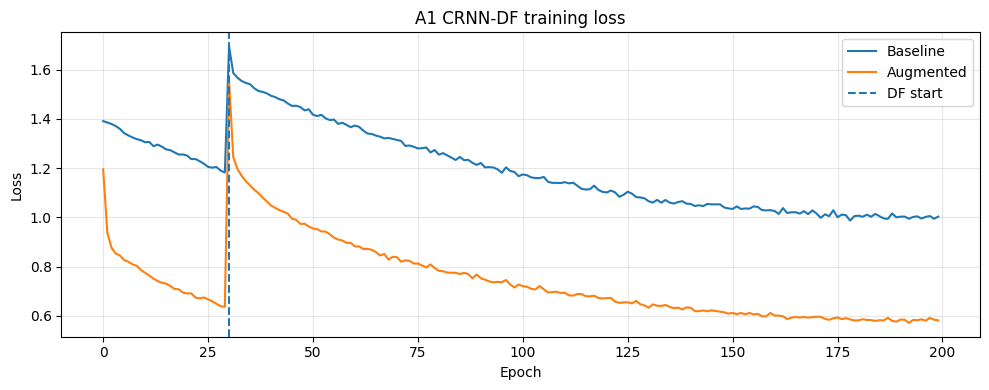

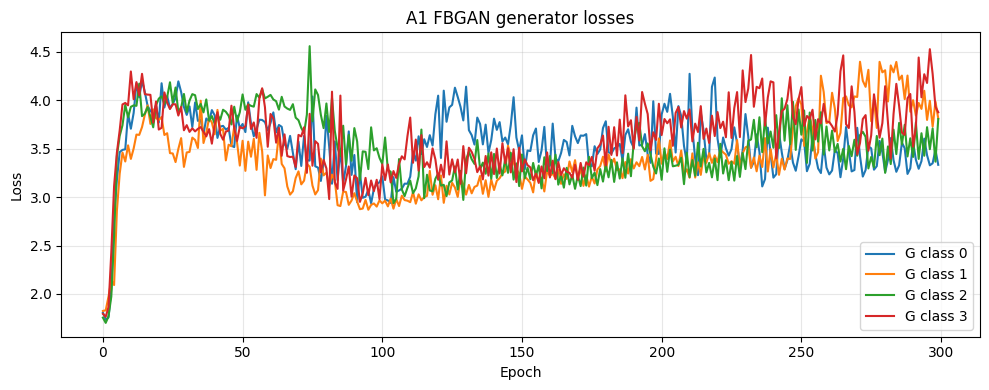

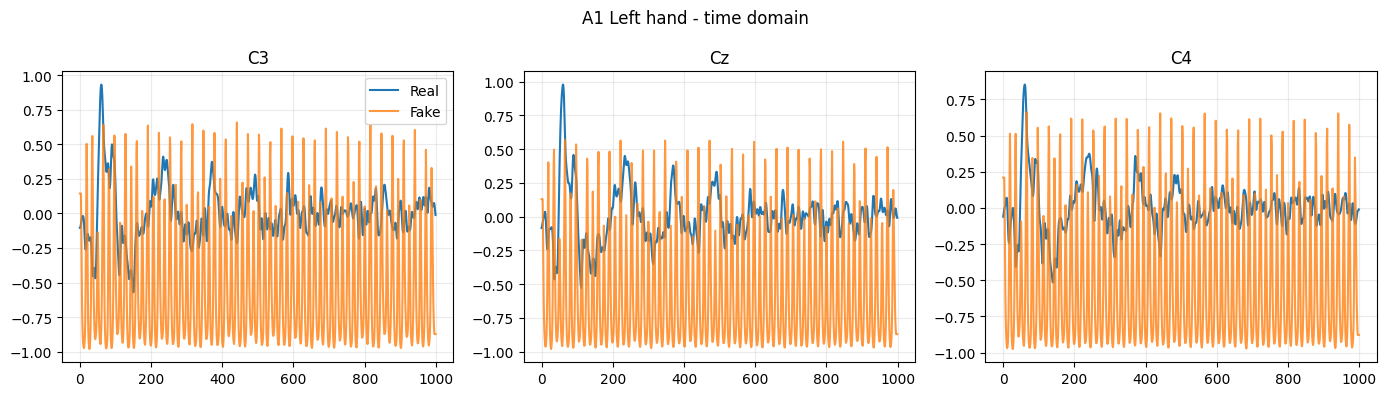

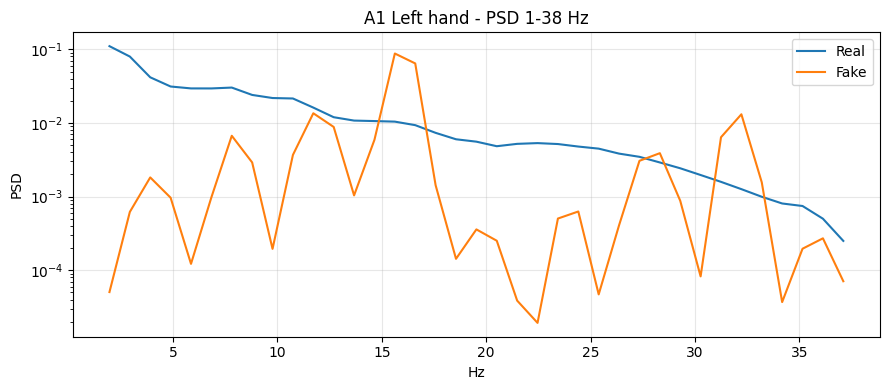

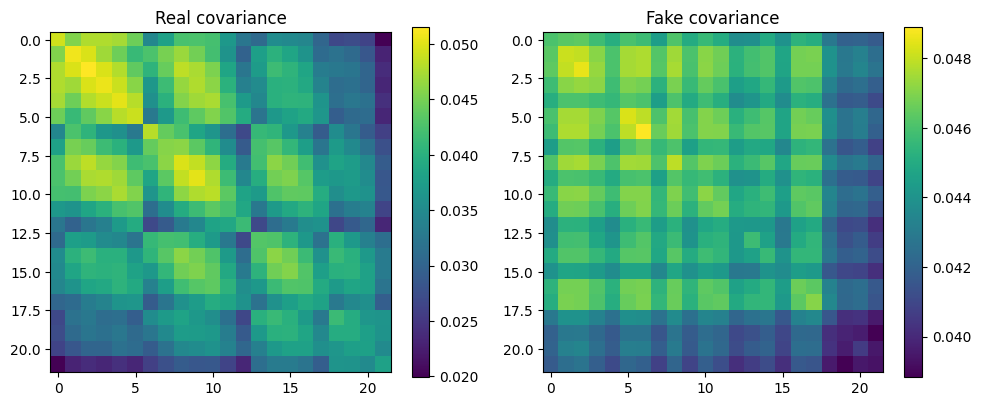

Covariance correlation: 0.5652525960681056

DEMO SUMMARY
{'baseline_acc': 43.40277777777778, 'aug_acc': 48.61111111111111, 'baseline_pred': array([2, 0, 3, 0, 1, 0, 1, 3, 1, 3, 0, 2, 1, 3, 2, 0, 3, 3, 2, 0, 0, 3,
       2, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 0, 1, 0, 1, 3, 0, 3, 0, 3, 3, 0,
       2, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 3, 1, 2, 1, 0, 0, 1, 0, 1, 0, 0,
       2, 1, 1, 1, 3, 3, 0, 0, 0, 0, 2, 3, 0, 0, 1, 2, 0, 3, 2, 1, 0, 0,
       0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 1, 2, 0, 2, 3, 0,
       0, 0, 1, 0, 3, 3, 0, 3, 1, 3, 0, 1, 0, 0, 0, 1, 0, 0, 1, 3, 3, 0,
       2, 1, 3, 1, 1, 3, 0, 0, 1, 1, 0, 0, 0, 3, 0, 2, 2, 3, 0, 0, 2, 0,
       3, 0, 3, 0, 0, 1, 1, 3, 0, 2, 1, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 2, 1, 3, 0, 0, 0, 0, 1, 0, 0,
       3, 3, 0, 3, 0, 1, 0, 2, 2, 2, 0, 1, 0, 0, 3, 0, 1, 3, 1, 3, 3, 1,
       0, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 3, 0, 0,

In [24]:
# ================================================================

demo = None

if RUN_DEMO:
    demo = run_fold(
        DEMO_SUBJECT,
        plots=True,
    )

    print(
        "\nDEMO SUMMARY"
    )

    print(demo)

    print(
        "Paper references:",
        PAPER_CRNN[DEMO_SUBJECT],
        PAPER_GAN[DEMO_SUBJECT],
    )

In [25]:
# ================================================================
# 12. FULL LOSO

In [26]:
# ================================================================

results = {}

if RUN_FULL_LOSO:
    total_start = time.time()

    subject_list = sorted(
        np.unique(subjects),
        key=lambda z: int(z),
    )

    for subject_id in subject_list:
        results[subject_id] = run_fold(
            subject_id,
            plots=False,
        )

        gc.collect()

        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()

        # Save after every subject.
        with open(
            "paper_faithful_results.pkl",
            "wb",
        ) as f:
            pickle.dump(
                results,
                f,
            )

    print(
        "\n"
        + "=" * 72
    )

    print(
        "FINAL PAPER REPLICATION RESULTS"
    )

    print(
        "=" * 72
    )

    for subject_id, result in results.items():
        print(
            f"A{subject_id}: "
            f"baseline={result['baseline_acc']:.2f}% | "
            f"FBGAN={result['aug_acc']:.2f}% | "
            f"paper={PAPER_GAN[subject_id]:.2f}%"
        )

    baseline_values = np.array(
        [
            result["baseline_acc"]
            for result in results.values()
        ],
        dtype=float,
    )

    augmented_values = np.array(
        [
            result["aug_acc"]
            for result in results.values()
        ],
        dtype=float,
    )

    print(
        f"\nBaseline mean +/- std: "
        f"{baseline_values.mean():.2f} +/- "
        f"{baseline_values.std():.2f}%"
    )

    print(
        f"FBGAN mean +/- std: "
        f"{augmented_values.mean():.2f} +/- "
        f"{augmented_values.std():.2f}%"
    )

    print(
        "Paper CRNN-DF: 63.52 +/- 10.70%"
    )

    print(
        "Paper + FBGAN: 72.74 +/- 10.44%"
    )

    # ------------------------------------------------------------
    # Subject-wise comparison
    # ------------------------------------------------------------

    subject_ids = sorted(
        results,
        key=lambda z: int(z),
    )

    x = np.arange(
        len(subject_ids)
    )

    width = 0.2

    plt.figure(figsize=(15, 6))

    plt.bar(
        x - 1.5 * width,
        [
            results[s]["baseline_acc"]
            for s in subject_ids
        ],
        width,
        label="Our CRNN-DF",
    )

    plt.bar(
        x - 0.5 * width,
        [
            results[s]["aug_acc"]
            for s in subject_ids
        ],
        width,
        label="Our + FBGAN",
    )

    plt.bar(
        x + 0.5 * width,
        [
            PAPER_CRNN[s]
            for s in subject_ids
        ],
        width,
        label="Paper CRNN-DF",
    )

    plt.bar(
        x + 1.5 * width,
        [
            PAPER_GAN[s]
            for s in subject_ids
        ],
        width,
        label="Paper + FBGAN",
    )

    plt.xticks(
        x,
        [
            f"A{s}"
            for s in subject_ids
        ],
    )

    plt.ylabel("Accuracy (%)")

    plt.title(
        "Subject-wise replication vs paper"
    )

    plt.grid(
        axis="y",
        alpha=0.3,
    )

    plt.legend(
        ncol=2
    )

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Aggregate confusion matrices
    # ------------------------------------------------------------

    y_true_all = np.concatenate(
        [
            results[s]["y_true"]
            for s in subject_ids
        ]
    )

    for title, prediction_key in [
        (
            "CRNN-DF",
            "baseline_pred",
        ),
        (
            "CRNN-DF + FBGAN",
            "aug_pred",
        ),
    ]:
        y_pred_all = np.concatenate(
            [
                results[s][prediction_key]
                for s in subject_ids
            ]
        )

        cm = confusion_matrix(
            y_true_all,
            y_pred_all,
            normalize="true",
        ) * 100.0

        plt.figure(figsize=(6, 5))

        image = plt.imshow(
            cm,
            vmin=0,
            vmax=100,
        )

        plt.colorbar(
            image,
            label="%",
        )

        plt.xticks(
            range(N_CLASSES),
            CLASSES,
            rotation=30,
            ha="right",
        )

        plt.yticks(
            range(N_CLASSES),
            CLASSES,
        )

        plt.title(
            "Aggregate confusion matrix - "
            + title
        )

        for i in range(N_CLASSES):
            for j in range(N_CLASSES):
                plt.text(
                    j,
                    i,
                    f"{cm[i, j]:.0f}",
                    ha="center",
                    va="center",
                )

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Save into bundle
    # ------------------------------------------------------------

    bundle[
        "paper_faithful_replication"
    ] = results

    bundle[
        "paper_faithful_mean_baseline"
    ] = float(
        baseline_values.mean()
    )

    bundle[
        "paper_faithful_mean_fbgan"
    ] = float(
        augmented_values.mean()
    )

    with open(
        BUNDLE_PATH,
        "wb",
    ) as f:
        pickle.dump(
            bundle,
            f,
        )

    print(
        "\nSaved results."
    )

    print(
        "Total minutes:",
        (
            time.time()
            - total_start
        ) / 60.0,
    )